# Fase 1 — Caracterização estatística univariada

Este notebook caracteriza as distribuições marginais dos **12 canais ERA5** e do **alvo de radar** do dataset CorrDiff 2011–2024.

A análise mantém deliberadamente dois domínios do alvo separados:

- `target_stored_valid`: valor efetivamente armazenado no Zarr, após `log1p`;
- `target_radar_legend_valid`: `expm1(target)`, que reconstrói o valor numérico da legenda do radar **após** o `clip(min=0)` aplicado pelo builder.

> **Importante:** o builder chama esse campo de refletividade, mas não declara formalmente a unidade física. Portanto, neste notebook o eixo é chamado de **valor numérico da legenda de refletividade**, e não automaticamente de dBZ.

A Fase 1 usa uma amostra de blocos Zarr espalhados ao longo de todo o período para estudar forma de distribuição, quantis, assimetria e caudas. Quando os artefatos da Fase 0 estão disponíveis, médias/desvios/min/max exatos e taxas globais de eventos da varredura completa são usados como referência.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

cwd = Path.cwd()
if (cwd / "analysis_outputs").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "analysis_outputs").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

OUT = PROJECT_ROOT / "analysis_outputs" / "01_univariate"
PHASE0 = PROJECT_ROOT / "analysis_outputs" / "00_quality"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Phase 1 output:", OUT)
assert OUT.exists(), f"Execute primeiro scripts/01_compute_univariate_stats.py. Diretório ausente: {OUT}"


PROJECT_ROOT: /home/vsantos/repositories/rionowcastdf
Phase 1 output: /home/vsantos/repositories/rionowcastdf/analysis_outputs/01_univariate


In [2]:
def load_parquet(name):
    path = OUT / name
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()

def load_json_file(path):
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

summary = load_json_file(OUT / "analysis_summary.json")
input_summary = load_parquet("input_summary.parquet")
input_quantiles = load_parquet("input_quantiles.parquet")
input_hist = load_parquet("input_histograms.parquet")
rh_quality = load_parquet("relative_humidity_quality.parquet")
target_summary = load_parquet("target_summary.parquet")
target_quantiles = load_parquet("target_quantiles.parquet")
target_hist = load_parquet("target_histograms.parquet")
target_rates_sampled = load_parquet("target_threshold_rates_sampled.parquet")
target_rates_reference = load_parquet("target_threshold_rates_reference.parquet")
sampling_blocks = load_parquet("sampling_blocks.parquet")
samples = np.load(OUT / "univariate_samples.npz")

summary


{'phase': 1,
 'version': 'phase1-univariate-v1',
 'dataset': {'zarr_path': 'datasets/corrdiff_2011_2024/train.zarr',
  'num_patches': 1132464,
  'channels': ['tcwv',
   't2m',
   'u10',
   'v10',
   't_850',
   'r_850',
   'u_850',
   'v_850',
   't_500',
   'r_500',
   'u_500',
   'v_500'],
  'input_shape': [1132464, 12, 32, 32],
  'target_shape': [1132464, 1, 32, 32],
  'mask_shape': [1132464, 1, 32, 32],
  'target_transform': 'log1p'},
 'sampling': {'strategy': 'systematic',
  'seed': 20260914,
  'zarr_chunk_first_dimension': 256,
  'block_size': 256,
  'selected_block_count': 128,
  'sampled_patch_count': 32768,
  'requested_sample_patches': 32768,
  'reservoir_values_per_channel_limit': 300000,
  'representativeness_vs_phase0': {'phase0_reference_available': True,
   'max_abs_sample_mean_difference_in_phase0_std': 0.12753118684734657,
   'max_sample_std_relative_difference': 0.08665198246020459}},
 'radar_target': {'stored_domain': 'log1p after invalid fill and clip(min=0)',
  're

## 1. Cobertura da amostragem usada na Fase 1

A Fase 0 já percorreu o dataset completo. Para não repetir desnecessariamente dezenas de bilhões de valores ERA5, a Fase 1 lê **blocos completos do Zarr** distribuídos ao longo de todo o dataset e compara as estatísticas amostrais com as estatísticas exatas da Fase 0.

O objetivo desta seção é verificar se a amostra é representativa antes de interpretar histogramas, quantis, assimetria e curtose.


In [3]:
sampling_info = summary.get("sampling", {})
pd.DataFrame([
    {"Item": "Patches solicitados", "Valor": sampling_info.get("requested_sample_patches")},
    {"Item": "Patches efetivamente lidos", "Valor": sampling_info.get("sampled_patch_count")},
    {"Item": "Blocos selecionados", "Valor": sampling_info.get("selected_block_count")},
    {"Item": "Tamanho do bloco", "Valor": sampling_info.get("block_size")},
    {"Item": "Estratégia", "Valor": sampling_info.get("strategy")},
    {"Item": "Reservoir máximo por variável", "Valor": sampling_info.get("reservoir_values_per_channel_limit")},
])


,Item,Valor
0,Patches solicitados,32768
1,Patches efetivamente lidos,32768
2,Blocos selecionados,128
3,Tamanho do bloco,256
4,Estratégia,systematic
5,Reservoir máximo por variável,300000


In [4]:
cols = [
    "channel", "expected_unit", "sampled_mean", "sampled_std",
    "phase0_exact_mean", "phase0_exact_std",
    "sample_mean_diff_in_phase0_std", "sample_std_relative_diff_vs_phase0"
]
available_cols = [c for c in cols if c in input_summary.columns]
input_summary[available_cols].round(6)


,channel,expected_unit,sampled_mean,sampled_std,phase0_exact_mean,phase0_exact_std,sample_mean_diff_in_phase0_std,sample_std_relative_diff_vs_phase0
0,tcwv,kg m^-2,36.708472,10.845037,36.219420,11.297360,0.043289,0.040038
1,t2m,K,296.277757,3.265778,296.284935,3.399368,0.002112,0.039299
2,u10,m s^-1,-1.049775,2.845741,-1.047842,2.739994,0.000706,0.038594
3,v10,m s^-1,0.188119,2.095751,0.051507,2.106449,0.064854,0.005079
4,t_850,K,288.648664,3.437413,288.755047,3.536194,0.030084,0.027934
5,r_850,%,76.025142,16.913756,73.732359,17.978214,0.127531,0.059208
6,u_850,m s^-1,1.030981,3.439794,1.078007,3.626558,0.012967,0.051499
7,v_850,m s^-1,-1.458556,4.163557,-1.434992,3.973074,0.005931,0.047944
8,t_500,K,265.542622,1.983869,265.462980,2.172084,0.036666,0.086652
9,r_500,%,35.220242,31.873343,34.107492,31.357926,0.035485,0.016437


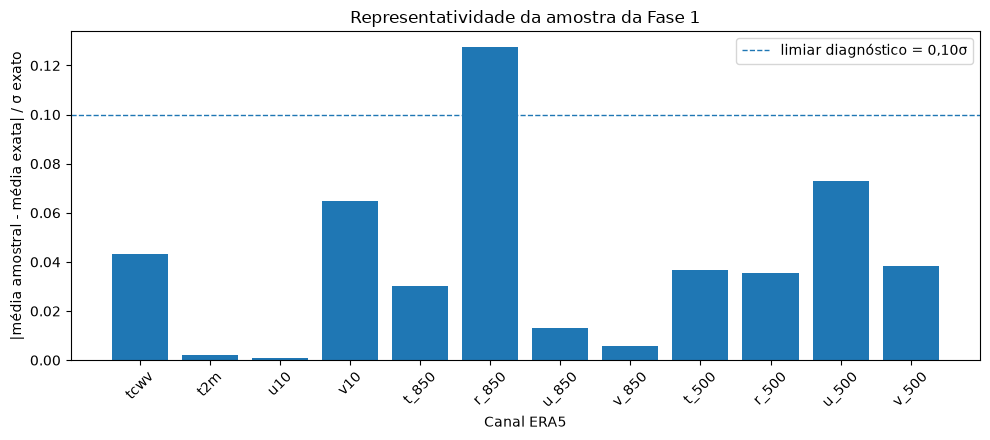

In [5]:
if "sample_mean_diff_in_phase0_std" in input_summary.columns:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(input_summary["channel"], input_summary["sample_mean_diff_in_phase0_std"])
    ax.axhline(0.10, linestyle="--", linewidth=1, label="limiar diagnóstico = 0,10σ")
    ax.set_ylabel("|média amostral - média exata| / σ exato")
    ax.set_xlabel("Canal ERA5")
    ax.set_title("Representatividade da amostra da Fase 1")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()


## 2. Resumo univariado dos 12 canais ERA5

As unidades abaixo são **unidades convencionais esperadas para as variáveis ERA5**, usadas como indicação de interpretação. A análise numérica em si é feita sobre os valores presentes no Zarr.


In [6]:
show_cols = [
    "channel_index", "channel", "expected_unit",
    "sampled_mean", "sampled_std", "sampled_min", "sampled_max",
    "sampled_skewness_from_reservoir", "sampled_excess_kurtosis_from_reservoir",
    "sampled_finite_ratio"
]
input_summary[[c for c in show_cols if c in input_summary.columns]].round(5)


,channel_index,channel,expected_unit,sampled_mean,sampled_std,sampled_min,sampled_max,sampled_skewness_from_reservoir,sampled_excess_kurtosis_from_reservoir,sampled_finite_ratio
0,0,tcwv,kg m^-2,36.70847,10.84504,10.17592,67.05702,0.02435,-0.89420,1.0
1,1,t2m,K,296.27776,3.26578,280.93439,310.40015,0.23714,0.68135,1.0
2,2,u10,m s^-1,-1.04977,2.84574,-12.17825,13.13794,-0.19684,1.13076,1.0
3,3,v10,m s^-1,0.18812,2.09575,-8.83302,11.49523,0.38511,1.03559,1.0
4,4,t_850,K,288.64866,3.43741,279.17923,296.78064,-0.32268,-0.69908,1.0
5,5,r_850,%,76.02514,16.91376,4.82062,104.77225,-0.57850,-0.31424,1.0
6,6,u_850,m s^-1,1.03098,3.43979,-11.66461,18.11930,0.44959,0.75493,1.0
7,7,v_850,m s^-1,-1.45856,4.16356,-20.16324,14.78246,0.04597,0.12650,1.0
8,8,t_500,K,265.54262,1.98387,258.93079,270.85522,-0.27116,-0.63828,1.0
9,9,r_500,%,35.22024,31.87334,-0.79204,110.05252,0.72503,-0.89961,1.0


### 2.1 Quantis

Os quantis são calculados sobre um conjunto limitado e distribuído de valores (`reservoir`) obtidos dos blocos amostrados. Eles são adequados para caracterizar a forma global das distribuições, mas não substituem uma climatologia espaço-temporal desduplicada.


In [7]:
quantile_table = input_quantiles.pivot(index="name", columns="quantile", values="value")
ordered = [c for c in ["p001", "p01", "p05", "p10", "p25", "p50", "p75", "p90", "p95", "p99", "p999"] if c in quantile_table.columns]
quantile_table[ordered].round(4)


quantile,p001,p01,p05,p10,p25,p50,p75,p90,p95,p99,p999
name,,,,,,,,,,,
r_500,1.1225,1.6320,3.0200,4.1506,7.2190,22.6312,60.2952,89.1912,95.9309,100.1521,103.0661
r_850,19.4155,32.6079,45.4433,52.4275,64.2058,78.1579,90.3568,96.6464,98.6515,100.2804,101.8835
t2m,285.1671,288.6005,291.1718,292.4793,294.1869,296.0823,298.2118,300.3975,302.0478,305.0161,307.4568
t_500,260.0403,260.8434,262.2305,262.8040,263.9691,265.8022,267.0116,268.0306,268.4968,269.2505,270.3779
t_850,280.1363,281.0261,282.6478,283.4784,286.1727,289.0142,291.3495,292.8753,293.7063,294.9935,295.7582
tcwv,13.1634,15.8649,19.1589,21.8936,28.4515,36.4320,45.1833,51.7465,54.2081,57.7716,61.4465
u10,-10.3029,-8.5952,-6.3176,-4.9050,-2.5161,-0.6729,0.4793,1.9644,3.3314,6.3683,9.9964
u_500,-10.4240,-8.7407,-2.9834,-1.0275,3.6220,8.2056,13.3935,17.9610,20.8564,28.6300,31.3179
u_850,-9.6281,-6.5968,-4.0657,-2.9834,-1.2226,0.6899,3.0801,5.5323,7.0344,10.8018,14.0559


### 2.2 Histogramas dos canais ERA5

Os gráficos abaixo mostram a distribuição efetivamente vista pelo treinamento em patches. Como `stride=16` e `patch_size=32`, pixels centrais do campo completo aparecem em mais de um patch; portanto, estes histogramas descrevem o **dataset de treinamento**, não uma climatologia espacial sem sobreposição.


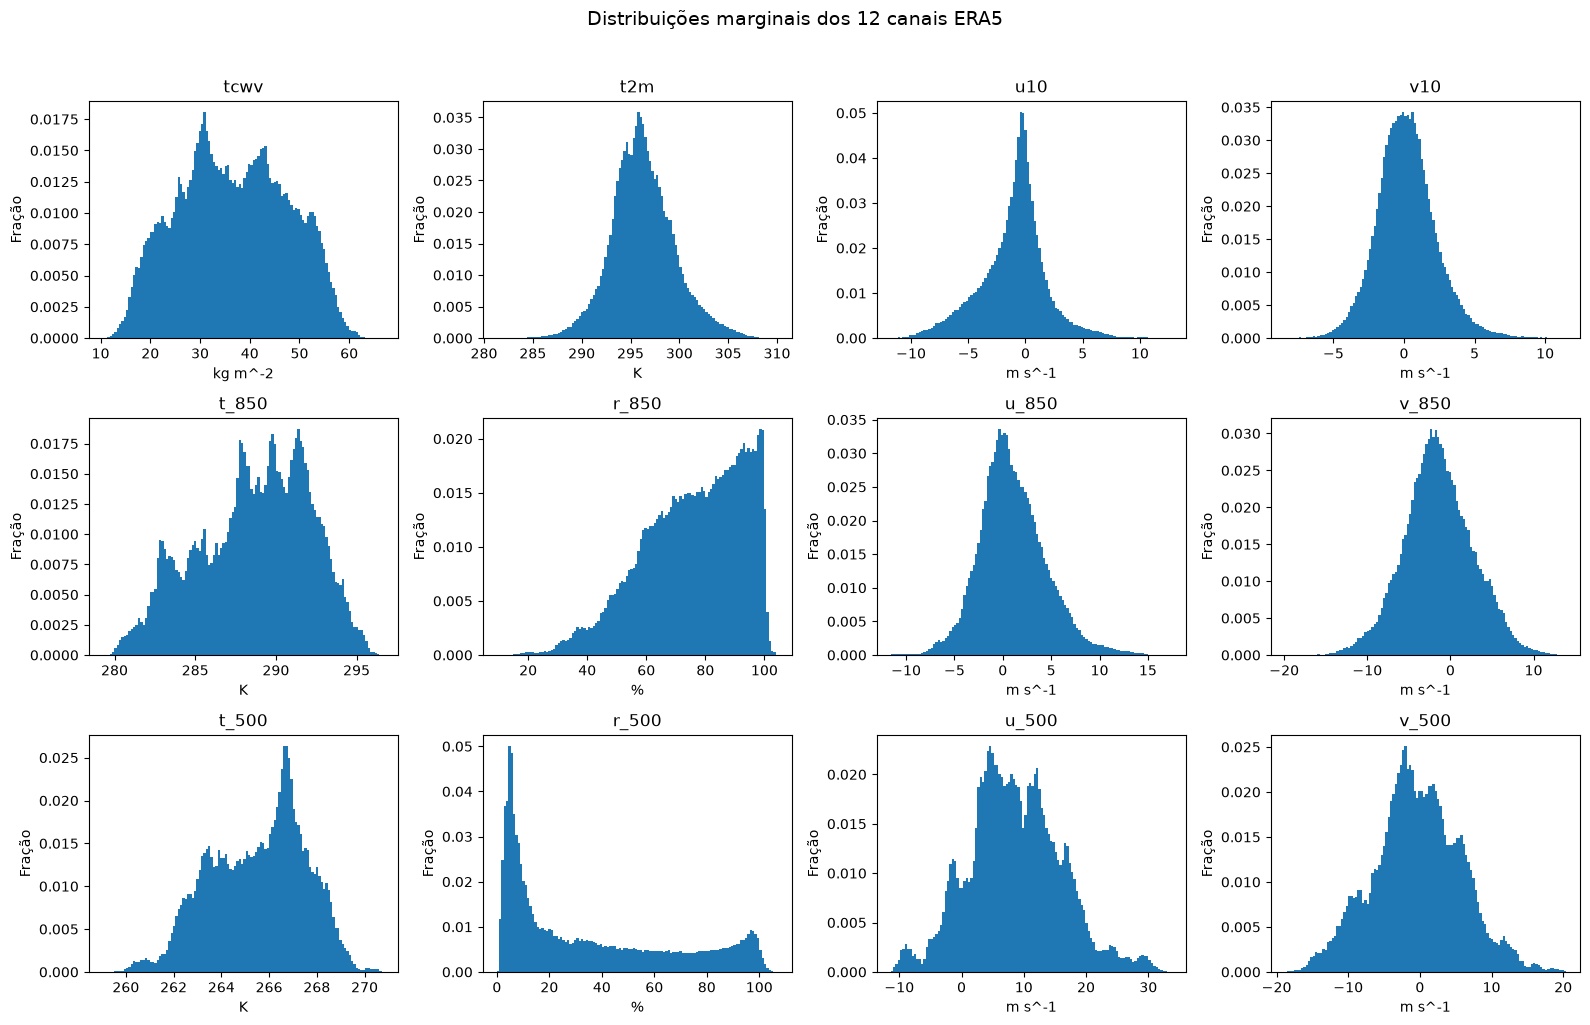

In [8]:
channels = input_summary.sort_values("channel_index")["channel"].tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()

for ax, channel in zip(axes, channels):
    h = input_hist[input_hist["name"] == channel]
    if h.empty:
        ax.set_visible(False)
        continue
    width = h["bin_right"] - h["bin_left"]
    ax.bar(h["bin_center"], h["ratio"], width=width, align="center")
    unit = input_summary.loc[input_summary["channel"] == channel, "expected_unit"].iloc[0]
    ax.set_title(channel)
    ax.set_xlabel(unit)
    ax.set_ylabel("Fração")

plt.suptitle("Distribuições marginais dos 12 canais ERA5", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 3. Temperatura: visualização adicional em °C

O dataset preserva a temperatura em Kelvin. Para interpretação visual, podemos converter apenas a cópia usada no gráfico por `°C = K - 273,15`, sem modificar o Zarr.


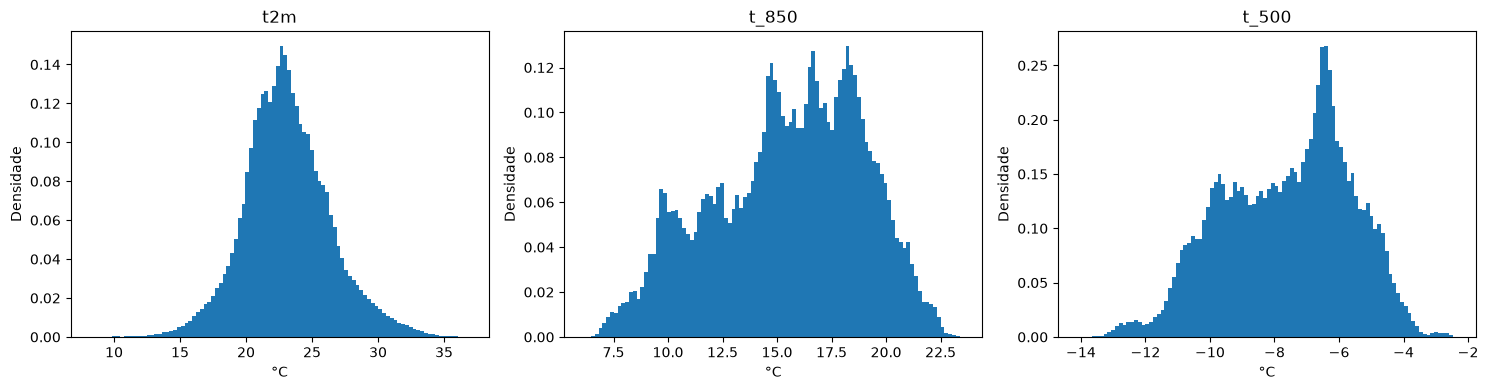

In [9]:
temp_channels = [c for c in ["t2m", "t_850", "t_500"] if f"input__{c}" in samples.files]
fig, axes = plt.subplots(1, len(temp_channels), figsize=(5 * max(len(temp_channels), 1), 4))
if len(temp_channels) == 1:
    axes = [axes]

for ax, channel in zip(axes, temp_channels):
    values_c = samples[f"input__{channel}"].astype(float) - 273.15
    ax.hist(values_c[np.isfinite(values_c)], bins=100, density=True)
    ax.set_title(channel)
    ax.set_xlabel("°C")
    ax.set_ylabel("Densidade")

plt.tight_layout()
plt.show()


## 4. Umidade relativa: valores fora de [0, 100]

Na Fase 0 observamos mínimos abaixo de 0% e máximos acima de 100% para `r_850` e `r_500`. Aqui quantificamos esse fenômeno na amostra da Fase 1, **sem recortar os dados**.

A decisão de limitar valores para modelagem só deve ocorrer depois de entendermos a origem e a frequência desses casos.


In [10]:
rh_quality.round(8)


,channel,expected_unit,sampled_finite_count,below_0_count,below_0_ratio,above_100_count,above_100_ratio,outside_0_100_count,outside_0_100_ratio,within_0_100_count,within_0_100_ratio,diagnostic_scope
0,r_850,%,33554432,0,0.000000,509373,0.015180,509373,0.015180,33045059,0.984819,sampled training-patch distribution; values ar...
1,r_500,%,33554432,90,0.000003,360862,0.010755,360952,0.010757,33193480,0.989243,sampled training-patch distribution; values ar...


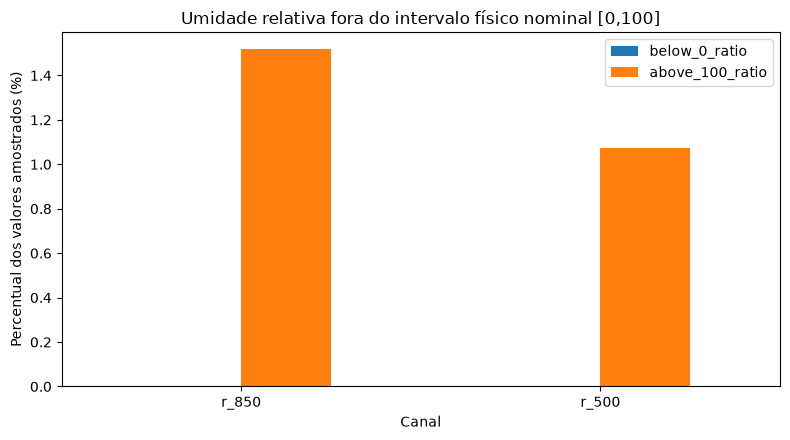

In [11]:
if not rh_quality.empty:
    plot = rh_quality.set_index("channel")[["below_0_ratio", "above_100_ratio"]] * 100
    ax = plot.plot(kind="bar", figsize=(8, 4.5))
    ax.set_ylabel("Percentual dos valores amostrados (%)")
    ax.set_xlabel("Canal")
    ax.set_title("Umidade relativa fora do intervalo físico nominal [0,100]")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()


## 5. Assimetria e caudas

Assimetria (`skewness`) e curtose excedente são úteis para detectar variáveis com distribuições fortemente não gaussianas, caudas pesadas e possível necessidade de tratamento específico de normalização ou análise por regimes.


In [12]:
shape_df = input_summary[[
    "channel", "sampled_skewness_from_reservoir", "sampled_excess_kurtosis_from_reservoir"
]].copy()
shape_df.round(4)


,channel,sampled_skewness_from_reservoir,sampled_excess_kurtosis_from_reservoir
0,tcwv,0.0243,-0.8942
1,t2m,0.2371,0.6814
2,u10,-0.1968,1.1308
3,v10,0.3851,1.0356
4,t_850,-0.3227,-0.6991
5,r_850,-0.5785,-0.3142
6,u_850,0.4496,0.7549
7,v_850,0.0460,0.1265
8,t_500,-0.2712,-0.6383
9,r_500,0.7250,-0.8996


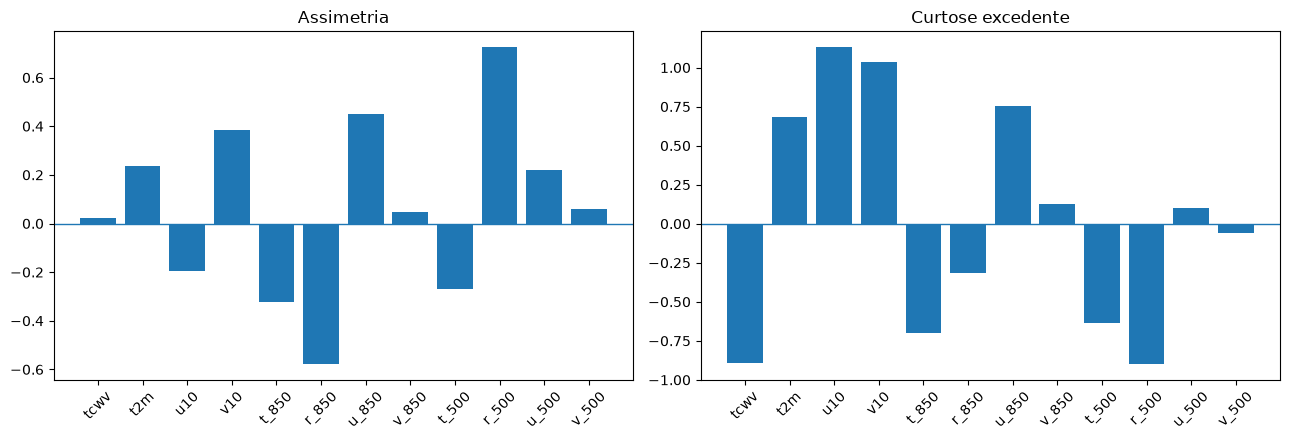

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(shape_df["channel"], shape_df["sampled_skewness_from_reservoir"])
axes[0].axhline(0, linewidth=1)
axes[0].set_title("Assimetria")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(shape_df["channel"], shape_df["sampled_excess_kurtosis_from_reservoir"])
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Curtose excedente")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 6. Radar: domínio armazenado versus domínio reconstruído

O builder grava:

\[
Y = \log(1 + \max(R,0))
\]

onde `R` é o valor numérico proveniente do cache do radar. Portanto:

\[
R_{clip} = \exp(Y) - 1
\]

O segundo domínio permite interpretar novamente os níveis numéricos da legenda. Valores negativos eventualmente presentes antes do `clip` **não podem ser recuperados**.


In [14]:
target_summary.round(6)


,name,domain,expected_unit,sampled_total_count,sampled_finite_count,sampled_finite_ratio,sampled_nan_count,sampled_posinf_count,sampled_neginf_count,sampled_mean,sampled_std,sampled_min,sampled_max,sampled_skewness_from_reservoir,sampled_excess_kurtosis_from_reservoir,reservoir_value_count,phase0_reference_available,phase0_exact_mean,phase0_exact_std,phase0_exact_min,phase0_exact_max,phase0_exact_finite_ratio
0,target_stored_valid,stored_log1p,log1p(radar-legend value),33554432,33554432,1.0,0,0,0,0.046694,0.387117,0.000000,3.931826,8.102256,63.963442,300000,True,0.048895,0.40047,0.0,3.931826,1.0
1,target_radar_legend_valid,reconstructed_expm1,radar-legend numeric value (physical unit not ...,33554432,33554432,1.0,0,0,0,0.362998,3.086362,0.000000,50.000000,8.768852,79.669861,300000,None,NaN,NaN,NaN,NaN,NaN
2,target_radar_legend_positive,reconstructed_expm1_positive_only,radar-legend numeric value (physical unit not ...,483508,483508,1.0,0,0,0,25.191276,5.966790,0.352162,50.000000,0.886157,0.927438,4433,None,NaN,NaN,NaN,NaN,NaN


In [15]:
q_target = target_quantiles.pivot(index="name", columns="quantile", values="value")
ordered = [c for c in ["p001", "p01", "p05", "p10", "p25", "p50", "p75", "p90", "p95", "p99", "p999"] if c in q_target.columns]
q_target[ordered].round(5)


quantile,p001,p01,p05,p10,p25,p50,p75,p90,p95,p99,p999
name,,,,,,,,,,,
target_radar_legend_positive,3.17791,17.38908,20.0,20.0,20.0,25.0,29.88277,35.0,36.4278,41.95483,45.00000
target_radar_legend_valid,0.00000,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0,0.0000,20.00000,35.00000
target_stored_valid,0.00000,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0,0.0000,3.04452,3.58352


### 6.1 Massa em zero e cauda positiva

Como o radar é altamente esparso, um histograma único tende a esconder completamente a distribuição dos eventos positivos. Por isso visualizamos separadamente:

1. distribuição completa, dominada por zero;
2. distribuição apenas dos valores positivos.


In [16]:
radar = samples["target_radar_legend_valid"].astype(float)
radar = radar[np.isfinite(radar)]
radar_pos = radar[radar > 0]

zero_ratio_sample = float(np.mean(radar == 0)) if radar.size else np.nan
positive_ratio_sample = float(np.mean(radar > 0)) if radar.size else np.nan

pd.DataFrame([
    {"Métrica": "Fração zero na amostra visual", "Valor": zero_ratio_sample},
    {"Métrica": "Fração positiva na amostra visual", "Valor": positive_ratio_sample},
    {"Métrica": "Valores válidos no reservoir", "Valor": radar.size},
    {"Métrica": "Valores positivos no reservoir", "Valor": radar_pos.size},
])


,Métrica,Valor
0,Fração zero na amostra visual,0.985223
1,Fração positiva na amostra visual,0.014777
2,Valores válidos no reservoir,300000.000000
3,Valores positivos no reservoir,4433.000000


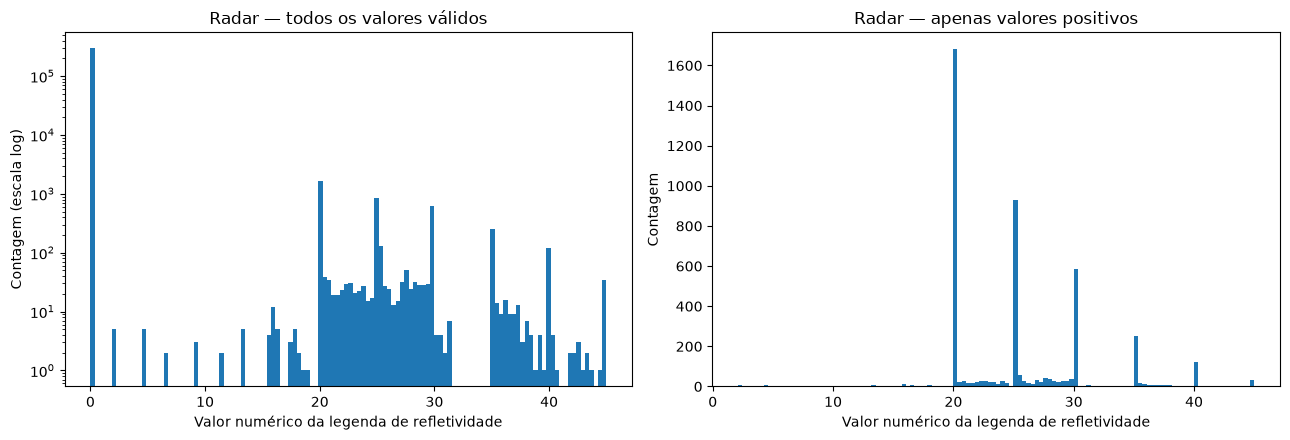

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(radar, bins=120)
axes[0].set_yscale("log")
axes[0].set_xlabel("Valor numérico da legenda de refletividade")
axes[0].set_ylabel("Contagem (escala log)")
axes[0].set_title("Radar — todos os valores válidos")

if radar_pos.size:
    axes[1].hist(radar_pos, bins=120)
axes[1].set_xlabel("Valor numérico da legenda de refletividade")
axes[1].set_ylabel("Contagem")
axes[1].set_title("Radar — apenas valores positivos")

plt.tight_layout()
plt.show()


### 6.2 ECDF dos eventos positivos

A ECDF ajuda a responder, entre os pixels com eco positivo, qual fração está abaixo de cada intensidade numérica da legenda.


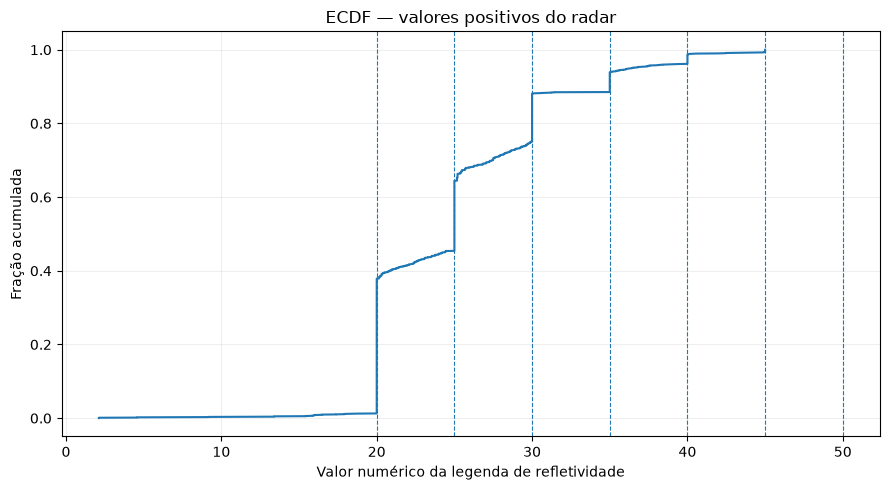

In [18]:
if radar_pos.size:
    sorted_pos = np.sort(radar_pos)
    ecdf = np.arange(1, sorted_pos.size + 1) / sorted_pos.size
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(sorted_pos, ecdf)
    for level in [20, 25, 30, 35, 40, 45, 50]:
        ax.axvline(level, linewidth=0.8, linestyle="--")
    ax.set_xlabel("Valor numérico da legenda de refletividade")
    ax.set_ylabel("Fração acumulada")
    ax.set_title("ECDF — valores positivos do radar")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


## 7. Desbalanceamento por limiar

Quando disponível, usamos `target_threshold_rates_reference.parquet`, produzido pela Fase 0 a partir da **varredura completa do target**. Caso contrário, usamos a estimativa dos blocos amostrados da Fase 1.

Duas grandezas devem ser distinguidas:

- `event_pixel_ratio`: proporção de pixels válidos que atingem o limiar;
- `event_patch_ratio`: proporção de patches que possuem pelo menos um pixel atingindo o limiar.


In [19]:
rates = target_rates_reference.copy() if not target_rates_reference.empty else target_rates_sampled.copy()
rates[[
    "condition", "legend_value_threshold", "event_pixel_ratio", "event_patch_ratio"
]].round(8)


,condition,legend_value_threshold,event_pixel_ratio,event_patch_ratio
0,> 0,0.0,1.478991e-02,0.297614
1,>= 20,20.0,1.461518e-02,0.296345
2,>= 25,25.0,8.833040e-03,0.217409
3,>= 30,30.0,5.203370e-03,0.160704
4,>= 35,35.0,3.501850e-03,0.122534
5,>= 40,40.0,1.382830e-03,0.076463
6,>= 45,45.0,7.476400e-04,0.028446
7,>= 50,50.0,1.500000e-07,0.000072


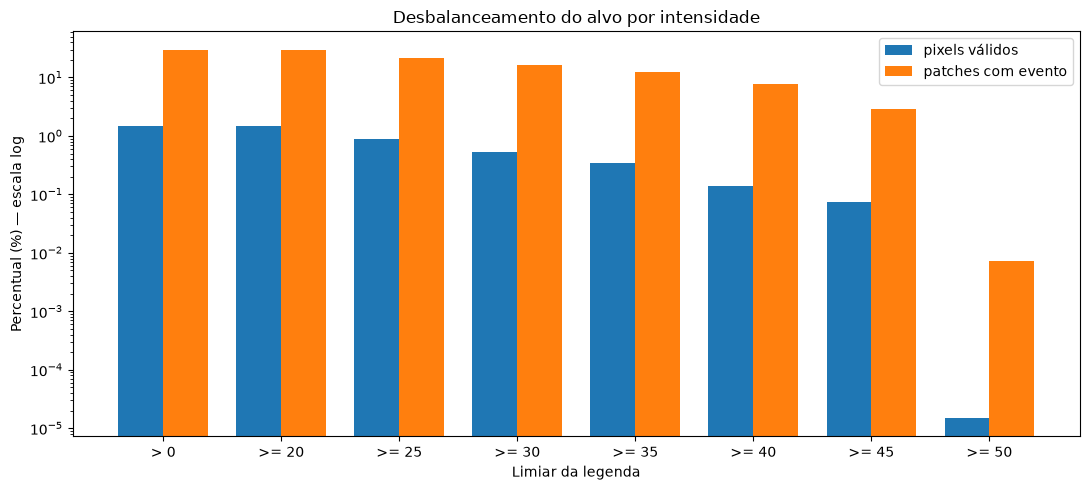

In [20]:
if not rates.empty:
    x = np.arange(len(rates))
    width = 0.38
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - width/2, rates["event_pixel_ratio"] * 100, width, label="pixels válidos")
    ax.bar(x + width/2, rates["event_patch_ratio"] * 100, width, label="patches com evento")
    ax.set_xticks(x)
    ax.set_xticklabels(rates["condition"])
    ax.set_yscale("log")
    ax.set_ylabel("Percentual (%) — escala log")
    ax.set_xlabel("Limiar da legenda")
    ax.set_title("Desbalanceamento do alvo por intensidade")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 8. Comparação padronizada entre os canais

A padronização abaixo é apenas exploratória. Ela permite comparar a forma das distribuições em uma mesma escala, usando os valores amostrados. Não altera o dataset.


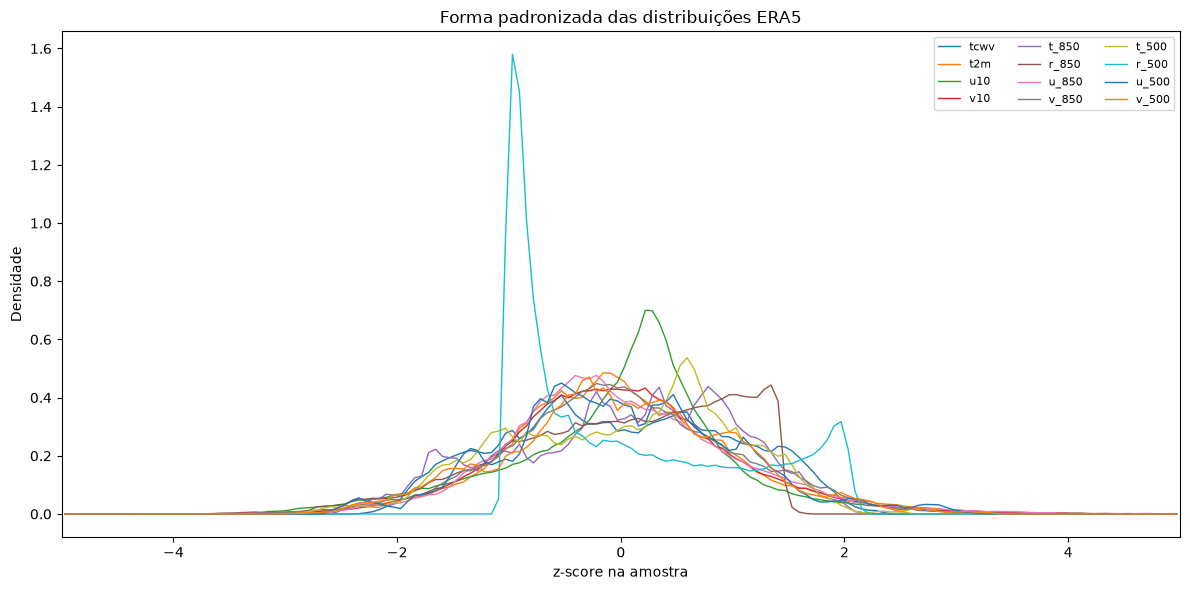

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
for channel in channels:
    key = f"input__{channel}"
    if key not in samples.files:
        continue
    values = samples[key].astype(float)
    values = values[np.isfinite(values)]
    if values.size == 0 or values.std() == 0:
        continue
    z = (values - values.mean()) / values.std()
    # histograma normalizado em grade comum para evitar milhões de pontos
    hist, edges = np.histogram(z, bins=np.linspace(-5, 5, 161), density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    ax.plot(centers, hist, linewidth=1, label=channel)

ax.set_xlim(-5, 5)
ax.set_xlabel("z-score na amostra")
ax.set_ylabel("Densidade")
ax.set_title("Forma padronizada das distribuições ERA5")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


## 9. Síntese automática da Fase 1

Esta célula transforma os principais diagnósticos em uma tabela compacta para registro metodológico.


In [22]:
rows = []
rep = summary.get("sampling", {}).get("representativeness_vs_phase0", {})
rows.append({
    "Checagem": "Representatividade da amostra vs Fase 0",
    "Status": "OK" if rep.get("max_abs_sample_mean_difference_in_phase0_std", 0) <= 0.10 else "REVISAR",
    "Detalhe": rep,
})

for _, row in rh_quality.iterrows():
    rows.append({
        "Checagem": f"{row['channel']} fora de [0,100]",
        "Status": "OBSERVAR" if row["outside_0_100_ratio"] > 0 else "OK",
        "Detalhe": f"{row['outside_0_100_ratio']:.6%}",
    })

if not rates.empty:
    gt0 = rates[rates["threshold"] == "gt_0"]
    if not gt0.empty:
        r = gt0.iloc[0]
        rows.append({
            "Checagem": "Esparsidade do radar",
            "Status": "IMPORTANTE",
            "Detalhe": f"pixels >0: {r['event_pixel_ratio']:.6%}; patches com >0: {r['event_patch_ratio']:.6%}",
        })

rows.append({
    "Checagem": "Unidade física da legenda do radar",
    "Status": "REVISAR",
    "Detalhe": "não declarada pelo builder; não rotular como dBZ sem documentação da fonte",
})

pd.DataFrame(rows)


,Checagem,Status,Detalhe
0,Representatividade da amostra vs Fase 0,REVISAR,"{'phase0_reference_available': True, 'max_abs_..."
1,"r_850 fora de [0,100]",OBSERVAR,1.518050%
2,"r_500 fora de [0,100]",OBSERVAR,1.075721%
3,Esparsidade do radar,IMPORTANTE,pixels >0: 1.478991%; patches com >0: 29.761388%
4,Unidade física da legenda do radar,REVISAR,não declarada pelo builder; não rotular como d...


## 10. Critérios para encerrar a Fase 1

A Fase 1 pode ser considerada concluída quando:

- a amostra distribuída reproduz adequadamente médias/desvios exatos da Fase 0;
- todas as 12 distribuições ERA5 foram caracterizadas por média, desvio, extremos, quantis, assimetria e curtose;
- valores de umidade relativa fora de `[0,100]` foram quantificados e documentados, sem tratamento silencioso;
- a distribuição do radar foi analisada separando `target` armazenado e `expm1(target)`;
- a massa em zero e as taxas por limiar foram quantificadas;
- ficou documentado que essas distribuições são **ponderadas pela estrutura de patches sobrepostos**;
- a unidade física da legenda do radar continua explicitamente separada da transformação numérica do builder.

Com isso, a próxima etapa é a **Fase 2 — variáveis derivadas fisicamente**, incluindo magnitude do vento, diferenças verticais e cisalhamento entre níveis, antes de avançarmos para as relações conjuntas ERA5 × radar.
